# Paper figures — sensitivity analyses

This notebook reads every run under `results/{lending,health}/` directly — no intermediate aggregation CSV is needed. Each run carries a `run_summary.json` stamped by `main.py` with `seed`, `sample_size`, `cv_splits`, `reward_variant`, `outcome_classifier`, and the rest of the configuration. The notebook groups runs by whichever metadata field is relevant for the figure, aggregates across seeds, and renders.

Discovery is **recursive** — runs may live directly under `results/lending/` (legacy flat layout) or under bucket subfolders such as `results/lending/rf_base_10000/` (the current layout). Both are picked up automatically.

**Figures produced**

* **Lending sensitivity vs. reward structure** (`base` / `mild` / `strictest`), with RF and `n = 10000`.
* **Lending sensitivity vs. predictive model** (RF / KNN), with `n = 10000` and base reward.
* **Healthcare results across seeds**.

All lending panels filter to `sample_size = 10000`. The reference actors (Oracle in lending; Outcome_Pred_Model / Outcome_Maxim) are drawn in fixed colors (black / grey) so they stay visually distinct from the actors that move with the swept axis.

In [30]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import sem

# Result folders and figure output sit next to this notebook.
RESULTS_DIR = Path('results')
FIG_DIR     = Path('figs')
FIG_DIR.mkdir(exist_ok=True)

CONF_DIR = Path('conf') / 'use_case'

print(f'Reading runs from   : {RESULTS_DIR.resolve()}')
print(f'Will save figures to: {FIG_DIR.resolve()}')

Reading runs from   : C:\Users\Vittoria\Desktop\part-train\new-code\results
Will save figures to: C:\Users\Vittoria\Desktop\part-train\new-code\figs


## Helpers

In [35]:
def short_model(target):
    """Map a sklearn dotted path to a short tag (rf / knn / xgb / lgbm)."""
    if not target:
        return None
    last = target.rsplit('.', 1)[-1].lower()
    if 'randomforest' in last: return 'rf'
    if 'kneighbors'   in last: return 'knn'
    if 'xgb'          in last: return 'xgb'
    if 'lightgbm'     in last: return 'lgbm'
    return last


def discover_runs(use_case, *, sample_size_only=None):
    """Recursively walk results/{use_case}/* and return one dict per run.

    Works with both the flat legacy layout (results/lending/run_*/) and the
    new bucketed layout (results/lending/<bucket>/run_*/).

    `sample_size_only`: if set, drops runs whose run_summary.json does not
    match this sample size. Use 10000 for lending to ignore the leftover
    sample-size sweep folder.
    """
    base = RESULTS_DIR / use_case
    if not base.exists():
        print(f'No results directory: {base}')
        return []
    runs = []
    for sj in sorted(base.rglob('run_summary.json')):
        run_dir = sj.parent
        csv = run_dir / 'final_ranked_decision_metrics.csv'
        cv  = run_dir / 'cv_ranked_decision_metrics.csv'
        if not csv.exists():
            continue
        try:
            summary = json.loads(sj.read_text())
        except json.JSONDecodeError:
            continue
        if sample_size_only is not None and summary.get('sample_size') != sample_size_only:
            continue
        runs.append({
            'summary': summary,
            'csv':     pd.read_csv(csv),
            'cv_csv':  pd.read_csv(cv) if cv.exists() else None,
            'dir':     run_dir,
        })
    return runs


def load_use_case_yaml(use_case):
    path = CONF_DIR / f'{use_case}.yaml'
    with open(path) as f:
        return yaml.safe_load(f)


def build_comparison_dict(runs, axis_field, *, filter_fn=None):
    """Build {metric: {actor: {axis_value: {'results': [...], 'results_cv': [...]}}}}."""
    out = defaultdict(lambda: defaultdict(lambda: defaultdict(
        lambda: {'results': [], 'results_cv': []}
    )))
    for r in runs:
        s = r['summary']
        if filter_fn is not None and not filter_fn(s):
            continue
        if axis_field == 'model':
            axis_value = short_model(s.get('outcome_classifier'))
        else:
            axis_value = s.get(axis_field) or ('base' if axis_field == 'reward_variant' else None)
        if axis_value is None:
            continue
        df    = r['csv']
        df_cv = r['cv_csv']
        if 'Actor/Criterion' not in df.columns:
            continue
        metric_cols = [c for c in df.columns if c != 'Actor/Criterion'
                       and pd.api.types.is_numeric_dtype(df[c])]
        for _, row in df.iterrows():
            actor = row['Actor/Criterion']
            for col in metric_cols:
                out[col][actor][axis_value]['results'].append(float(row[col]))
                if df_cv is not None and 'Actor/Criterion' in df_cv.columns:
                    cv_match = df_cv[df_cv['Actor/Criterion'] == actor]
                    if not cv_match.empty and col in cv_match.columns:
                        try:
                            out[col][actor][axis_value]['results_cv'].append(float(cv_match.iloc[0][col]))
                        except (TypeError, ValueError):
                            pass
    return {m: {a: dict(av) for a, av in actors.items()} for m, actors in out.items()}

In [44]:
# Default plot style -- large fonts so the figures read in a two-column paper.
plt.rcParams.update({
    'font.size':         15,
    'axes.titlesize':    15,
    'axes.labelsize':    15,
    'xtick.labelsize':   15,
    'ytick.labelsize':   15,
    'legend.fontsize':   15,
    'figure.titlesize':  16,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

## Sensitivity panels

Same visual grammar across all four panels: actors on the y-axis, one subplot per metric, a horizontal error bar per (actor, axis-value) showing **mean ± SEM** across seeds. Reference actors (Oracle / Outcome_Pred_Model / Outcome_Maxim) use fixed colors so they stay visually distinct from the actors that move with the swept axis.

In [45]:
# Fixed colors for reference / baseline actors so they read consistently across every
# sensitivity panel. Oracle is the idealized upper bound; Outcome_Pred_Model and
# Outcome_Maxim are the prediction-only baselines.
ACTOR_OVERRIDE_COLORS = {
    'Oracle': 'black',
    'Outcome_Pred_Model': 'gray',
    'Outcome_Maxim': 'gray',
}


def visualize_sensitivity(data_dict, selected_metrics, y_order, axis_values_in_order, colors,
                          *, title=None, error='sem', figsize_per_metric=(4.8, 6.5)):
    n_metrics = len(selected_metrics)
    fig, axes = plt.subplots(1, n_metrics,
                             figsize=(figsize_per_metric[0] * n_metrics, figsize_per_metric[1]),
                             sharey=True)
    if n_metrics == 1:
        axes = [axes]
    y_positions = {actor: i for i, actor in enumerate(reversed(y_order))}

    # The legend MUST come from a non-overridden actor; otherwise every legend handle
    # inherits Oracle's black, which is misleading. Pick the first actor in y_order
    # whose color is the axis-value color (not the override).
    legend_actor = next((a for a in y_order if a not in ACTOR_OVERRIDE_COLORS), y_order[0])

    for ax_idx, metric in enumerate(selected_metrics):
        ax = axes[ax_idx]
        if metric not in data_dict:
            ax.text(0.5, 0.5, f'no data for\n{metric}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(metric.replace('_', ' '))
            continue
        for actor in y_order:
            if actor not in data_dict[metric]:
                continue
            for axis_value in axis_values_in_order:
                if axis_value not in data_dict[metric][actor]:
                    continue
                vals = data_dict[metric][actor][axis_value]['results']
                if not vals:
                    continue
                arr = np.asarray(vals, dtype=float)
                if error == 'sem' and len(arr) > 1:
                    err = float(sem(arr))
                elif error == 'std' and len(arr) > 1:
                    err = float(arr.std(ddof=1))
                else:
                    err = 0.0
                color = ACTOR_OVERRIDE_COLORS.get(actor, colors.get(axis_value, 'gray'))
                attach_label = (ax_idx == 0 and actor == legend_actor)
                ax.errorbar(arr.mean(), y_positions[actor],
                            xerr=err, fmt='o', color=color,
                            markersize=9, capsize=4, elinewidth=1.8, alpha=0.9,
                            label=str(axis_value) if attach_label else None)
        ax.set_title(metric.replace('_', ' '))
        ax.grid(alpha=0.25, axis='x', linestyle='--')

    axes[0].set_yticks(range(len(y_order)))
    axes[0].set_yticklabels(list(reversed(y_order)))

    handles, labels = [], []
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    if labels:
        fig.legend(handles, labels, loc='upper center',
                   bbox_to_anchor=(0.5, 1.02), ncol=len(labels), frameon=False)
    if title:
        fig.suptitle(title, y=1.08)
    plt.tight_layout()
    return fig


y_order_lending = [
    'Oracle', 'Outcome_Pred_Model',
    'Bank', 'Applicant', 'Regulatory',
    'Maximin', 'Nash Bargaining', 'Kalai-Smorodinsky',
    'Nash Social Welfare', 'Compromise Programming', 'Proportional Fairness',
]
y_order_health = [
    'Outcome_Maxim',
    'Parent', 'Healthcare_Provider', 'Policy_Maker',
    'Maximin', 'Nash Bargaining', 'Kalai-Smorodinsky',
    'Nash Social Welfare', 'Compromise Programming', 'Proportional Fairness',
]

# Lending sensitivity metrics.
lending_metrics = ['Accuracy', 'Demographic_Parity',
                   'Total_Profit', 'Total_Loss',
                   'Percent_Grant', 'Percent_Grant_lower']

# Health sensitivity metrics. The framework writes 'Percentage_treated' (lowercase t).
health_metrics = ['Accuracy', 'Demographic_Parity',
                  'Percentage_treated', 'Avg_outcome_difference',
                  'Mean_outcome_treated']

PALETTE = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd', '#8c564b']

# Filter to sample_size=10000 -- the legacy sample-size sweep folders are ignored.
lending_runs = discover_runs('lending', sample_size_only=10000)
print(f'Discovered {len(lending_runs)} lending runs at sample_size=10000.')
for r in lending_runs[:5]:
    s = r['summary']
    print(f"  seed={s.get('seed')} sample={s.get('sample_size')} "
          f"reward={s.get('reward_variant')} model={short_model(s.get('outcome_classifier'))}")

Discovered 9 lending runs at sample_size=10000.
  seed=111 sample=10000 reward=base model=knn
  seed=1111 sample=10000 reward=base model=knn
  seed=42 sample=10000 reward=base model=knn
  seed=42 sample=10000 reward=base model=rf
  seed=111 sample=10000 reward=base model=rf


### Sensitivity to reward structure  (RF, n = 10000)

Reward variants covered: ['base', 'strictest']


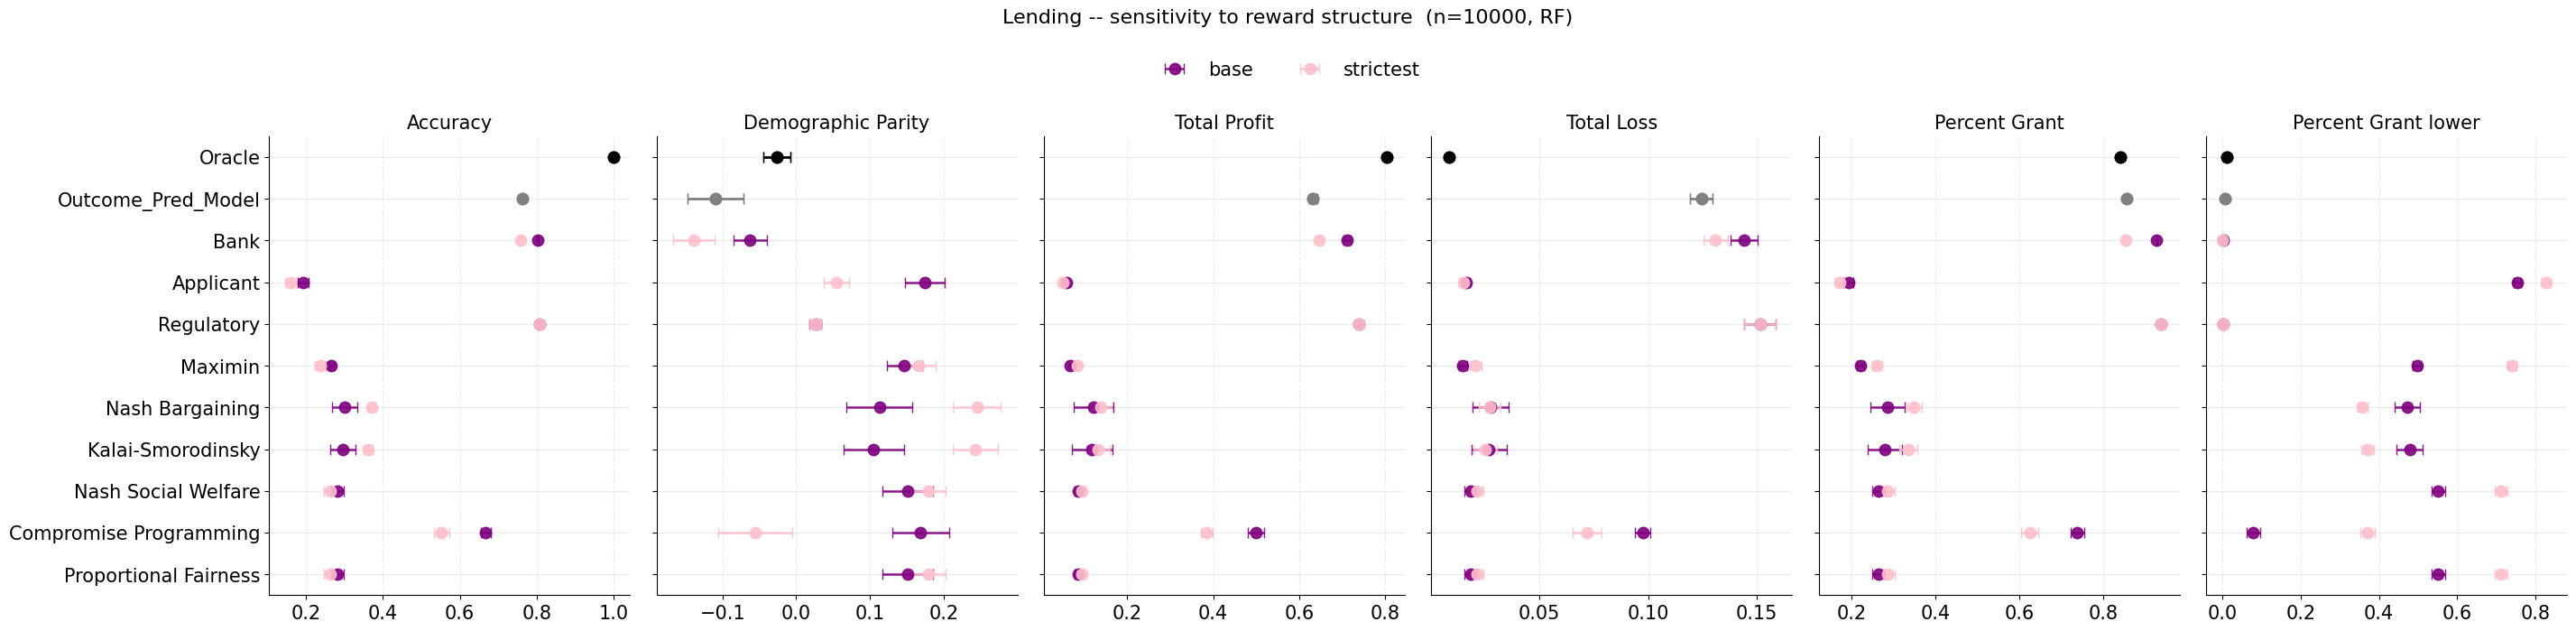

In [46]:
data_rv = build_comparison_dict(
    lending_runs, axis_field='reward_variant',
    filter_fn=lambda s: s.get('sample_size') == 10000
                        and short_model(s.get('outcome_classifier')) == 'rf',
)
reward_variants_seen = sorted({rv for m in data_rv.values() for a in m.values() for rv in a.keys()})
print('Reward variants covered:', reward_variants_seen)

colors_rv = {'base': 'purple', 'mild': 'red', 'strictest': 'pink'}
fig = visualize_sensitivity(data_rv, lending_metrics, y_order_lending,
                            reward_variants_seen, colors_rv,
                            title='Lending -- sensitivity to reward structure  (n=10000, RF)')
fig.savefig(FIG_DIR / 'fig3a_lending_reward_variant.png', dpi=200, bbox_inches='tight')
plt.show()

### Sensitivity to predictive model architecture  (n = 10000, base reward)

Models covered: ['knn', 'rf']


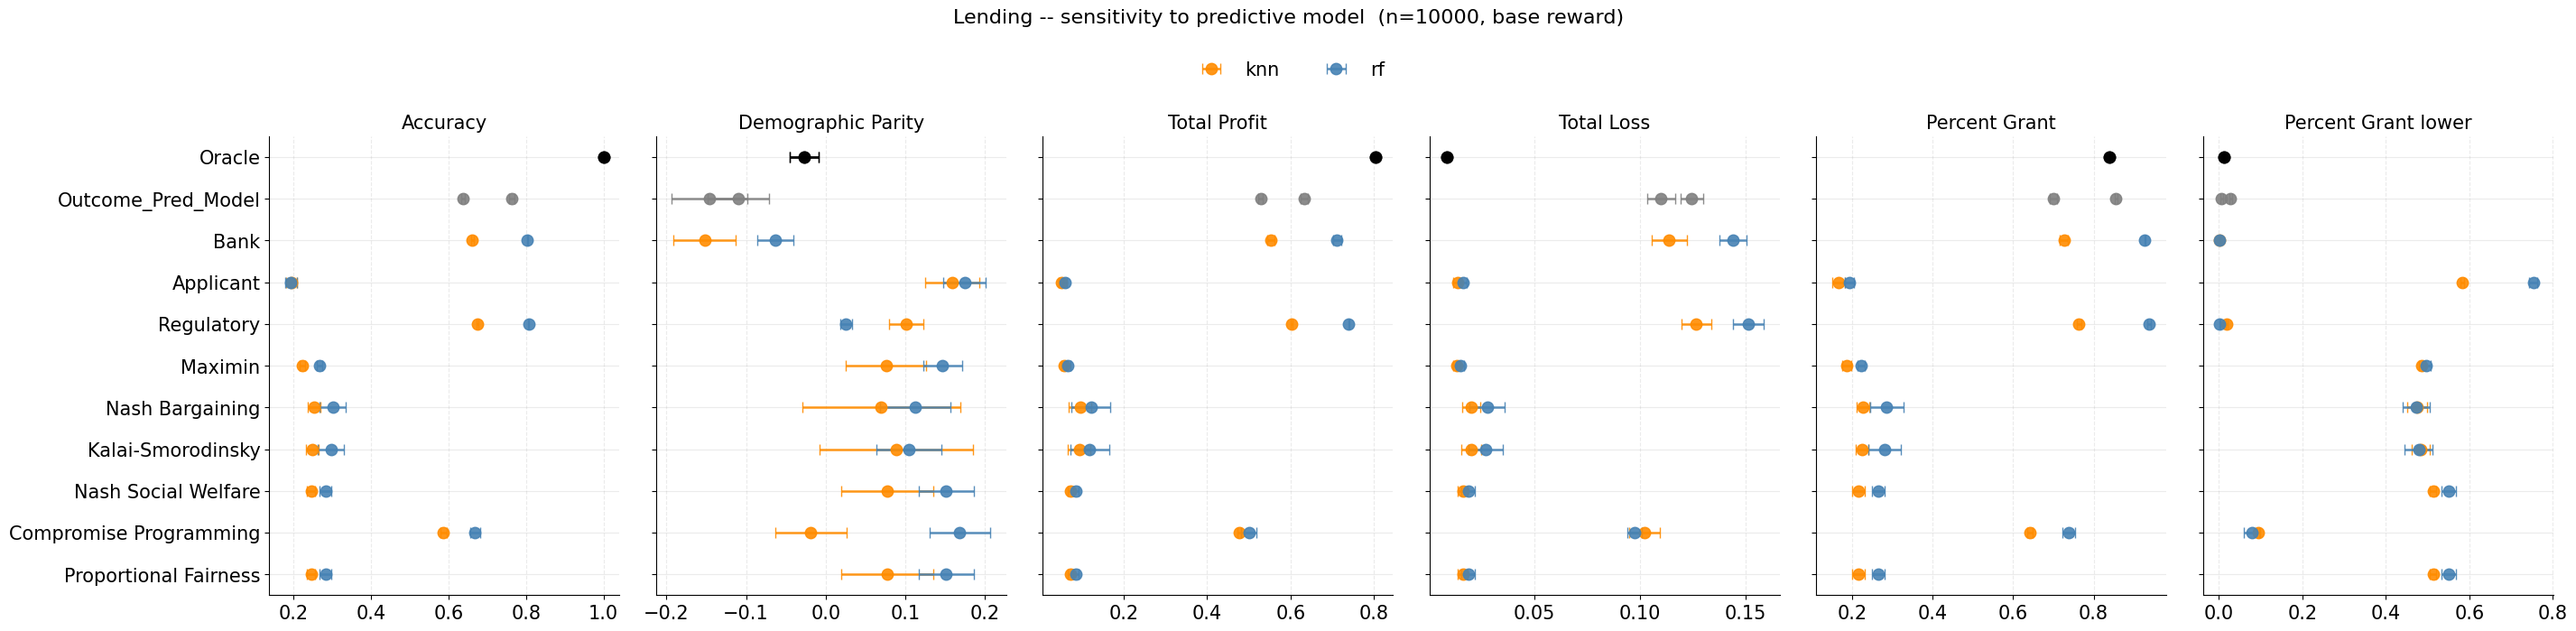

In [47]:
data_model = build_comparison_dict(
    lending_runs, axis_field='model',
    filter_fn=lambda s: s.get('sample_size') == 10000
                        and (s.get('reward_variant') or 'base') == 'base',
)
models_seen = sorted({m for metric in data_model.values() for a in metric.values() for m in a.keys()})
print('Models covered:', models_seen)

# Use distinct hues so the model axis colors don't collide with the gray override
# used for Outcome_Pred_Model.
colors_model = {'rf': 'steelblue', 'knn': 'darkorange', 'xgb': 'green', 'lgbm': 'brown'}
fig = visualize_sensitivity(data_model, lending_metrics, y_order_lending,
                            models_seen, colors_model,
                            title='Lending -- sensitivity to predictive model  (n=10000, base reward)')
fig.savefig(FIG_DIR / 'fig3b_lending_model.png', dpi=200, bbox_inches='tight')
plt.show()

### Healthcare results across seeds

Discovered 3 health runs.
Health sample sizes: [787]


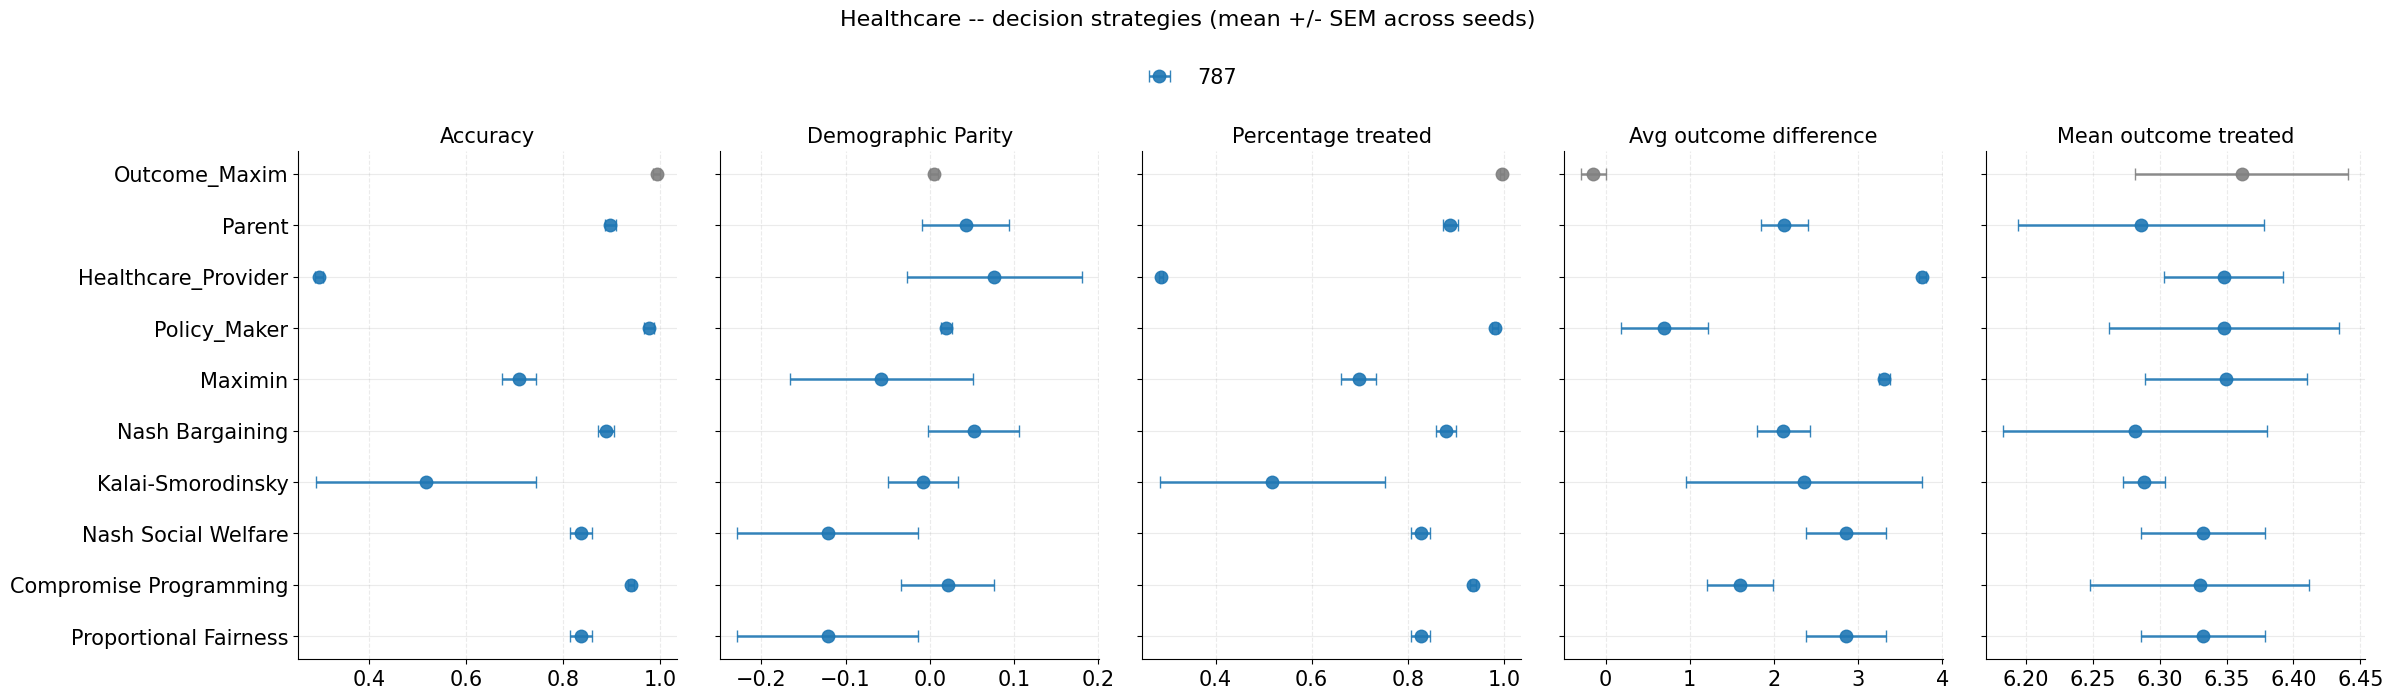

In [48]:
health_runs = discover_runs('health')
print(f'Discovered {len(health_runs)} health runs.')

data_health = build_comparison_dict(health_runs, axis_field='sample_size')
health_axis_values = sorted({ss for m in data_health.values() for a in m.values() for ss in a.keys()})
print('Health sample sizes:', health_axis_values)

colors_health = {ss: c for ss, c in zip(health_axis_values, PALETTE)}
fig = visualize_sensitivity(data_health, health_metrics, y_order_health,
                            health_axis_values, colors_health,
                            title='Healthcare -- decision strategies (mean +/- SEM across seeds)')
fig.savefig(FIG_DIR / 'fig3c_health.png', dpi=200, bbox_inches='tight')
plt.show()